# Notebook 5: Fine-Tuning a Transformer for Sentiment Classification

In this notebook we **fine-tune** a pretrained transformer (DistilBERT) on the **IMDb movie review** dataset for binary sentiment classification (positive / negative).

## Learning Objectives
- Understand the concept of transfer learning via fine-tuning
- Load and preprocess the IMDb dataset with Hugging Face `datasets`
- Fine-tune `distilbert-base-uncased` with the Hugging Face `Trainer` API
- Evaluate with accuracy, precision, recall, and F1
- Run inference on custom sentences

## Background
**Fine-tuning** adapts a pretrained language model to a specific downstream task by continuing training on a small, labelled dataset. The model has already learned rich language representations from large unlabelled corpora; fine-tuning simply nudges the weights to specialise for the target task. DistilBERT is a distilled version of BERT that retains ~97% of BERT's performance at 60% of its size and 2× its inference speed.

## 1. Install & Import Dependencies

In [1]:
# !pip install transformers datasets evaluate scikit-learn torch accelerate

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline,
)
import evaluate

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.11.0+cpu


## 2. Load and Explore the IMDb Dataset

In [3]:
# Load the IMDb dataset (25k train, 25k test reviews)
raw_dataset = load_dataset("imdb")
print(raw_dataset)
print(f"\nExample review (first 300 chars):\n{raw_dataset['train'][0]['text'][:300]}")
print(f"Label: {'Positive' if raw_dataset['train'][0]['label'] == 1 else 'Negative'}")

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Example review (first 300 chars):
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h
Label: Negative


In [ ]:
import matplotlib.pyplot as plt

# Class distribution
train_labels = raw_dataset['train']['label']
label_counts = [train_labels.count(0), train_labels.count(1)]

plt.figure(figsize=(5, 4))
plt.bar(['Negative (0)', 'Positive (1)'], label_counts, color=['tomato', 'mediumseagreen'])
plt.title('IMDb Training Set — Label Distribution')
plt.ylabel('Number of samples')
plt.tight_layout()
plt.show()

print(f"Negative: {label_counts[0]:,}")
print(f"Positive: {label_counts[1]:,}")

## 3. Tokenize the Dataset

In [4]:
MODEL_CHECKPOINT = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=256,
    )

# For demonstration we use a small subset to keep training fast on CPU.
# Remove the `.select(...)` calls to train on the full dataset.
TRAIN_SIZE = 2000   # increase for better accuracy
EVAL_SIZE  = 500

small_train = raw_dataset['train'].shuffle(seed=42).select(range(TRAIN_SIZE))
small_eval  = raw_dataset['test'].shuffle(seed=42).select(range(EVAL_SIZE))

tokenized_train = small_train.map(tokenize_function, batched=True)
tokenized_eval  = small_eval.map(tokenize_function,  batched=True)

# Remove the raw text column; Trainer only needs tensors
tokenized_train = tokenized_train.remove_columns(["text"])
tokenized_eval  = tokenized_eval.remove_columns(["text"])
tokenized_train.set_format("torch")
tokenized_eval.set_format("torch")

print(f"Train samples : {len(tokenized_train)}")
print(f"Eval  samples : {len(tokenized_eval)}")
print(f"Features      : {tokenized_train.features}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Train samples : 2000
Eval  samples : 500
Features      : {'label': ClassLabel(names=['neg', 'pos']), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}


## 4. Load the Model

In [5]:
id2label = {0: "NEGATIVE", 1: "POSITIVE"}
label2id = {"NEGATIVE": 0, "POSITIVE": 1}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)
print(f"Model loaded. Parameters: {model.num_parameters():,}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded. Parameters: 66,955,010


## 5. Define Training Arguments and Metrics

In [6]:
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=predictions, references=labels)


training_args = TrainingArguments(
    output_dir="/tmp/distilbert-imdb",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=100,
    weight_decay=0.01,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=50,
    report_to="none",       # disable W&B / other loggers
    use_cpu=not torch.cuda.is_available(),
)
print("Training arguments configured.")

Training arguments configured.


## 6. Fine-Tune with the Trainer API

In [7]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning...")
train_result = trainer.train()
print(f"\nTraining completed.")
print(f"Training loss      : {train_result.training_loss:.4f}")
print(f"Total runtime (s)  : {train_result.metrics['train_runtime']:.1f}")

Starting fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.567109,0.350000,0.852000
2,0.287591,0.343243,0.864000
3,0.152678,0.327355,0.874000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training completed.
Training loss      : 0.3443
Total runtime (s)  : 3929.0


## 7. Evaluate on the Test Set

In [8]:
eval_results = trainer.evaluate()
print(f"Evaluation results:")
for k, v in eval_results.items():
    if isinstance(v, float):
        print(f"  {k:<30}: {v:.4f}")
    else:
        print(f"  {k:<30}: {v}")

Training Loss,Validation Loss,Epoch,Accuracy
0.152678,0.327355,3,0.874000


Evaluation results:
  eval_loss                     : 0.3274
  eval_accuracy                 : 0.8740


Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.83      0.87       254
    Positive       0.84      0.92      0.88       246

    accuracy                           0.87       500
   macro avg       0.88      0.87      0.87       500
weighted avg       0.88      0.87      0.87       500



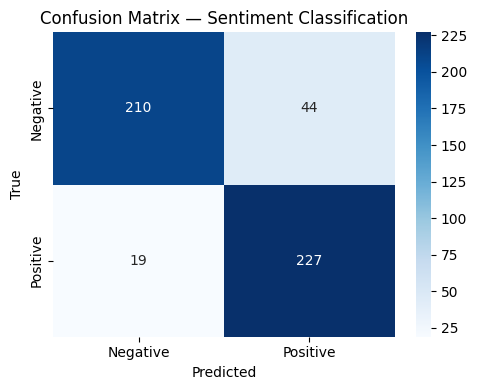

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Get predictions on the eval set
predictions_output = trainer.predict(tokenized_eval)
preds = np.argmax(predictions_output.predictions, axis=-1)
labels = predictions_output.label_ids

print("Classification Report:")
print(classification_report(labels, preds, target_names=["Negative", "Positive"]))

# Confusion matrix
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix — Sentiment Classification')
plt.tight_layout()
plt.show()

## 8. Inference on Custom Sentences

In [11]:
# Save the fine-tuned model temporarily
trainer.save_model("/tmp/distilbert-imdb-best")
tokenizer.save_pretrained("/tmp/distilbert-imdb-best")

# Load into inference pipeline
sentiment_pipeline = pipeline(
    "text-classification",
    model="/tmp/distilbert-imdb-best",
    tokenizer="/tmp/distilbert-imdb-best",
    device=0 if torch.cuda.is_available() else -1,
    truncation=True,
    max_length=256,
)

test_reviews = [
    "This movie was absolutely fantastic! The acting was superb and the plot kept me on the edge of my seat.",
    "Terrible film. The story made no sense and the special effects were laughably bad.",
    "It was an okay movie. Not great, not terrible. Some parts were enjoyable, others were boring.",
    "One of the best films I have ever seen. A masterpiece of cinema.",
    "I walked out after 30 minutes. Complete waste of time and money.",
]

print("Sentiment Analysis Results:")
print("-" * 70)
for review in test_reviews:
    result = sentiment_pipeline(review)[0]
    label_icon = "😊" if result['label'] == 'POSITIVE' else "😞"
    print(f"{label_icon} [{result['label']:<8} {result['score']:.4f}] {review[:70]}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Sentiment Analysis Results:
----------------------------------------------------------------------
😊 [POSITIVE 0.9768] This movie was absolutely fantastic! The acting was superb and the plo
😞 [NEGATIVE 0.9719] Terrible film. The story made no sense and the special effects were la
😞 [NEGATIVE 0.7522] It was an okay movie. Not great, not terrible. Some parts were enjoyab
😊 [POSITIVE 0.9765] One of the best films I have ever seen. A masterpiece of cinema.
😞 [NEGATIVE 0.9637] I walked out after 30 minutes. Complete waste of time and money.


## 9. Training Loss Curve

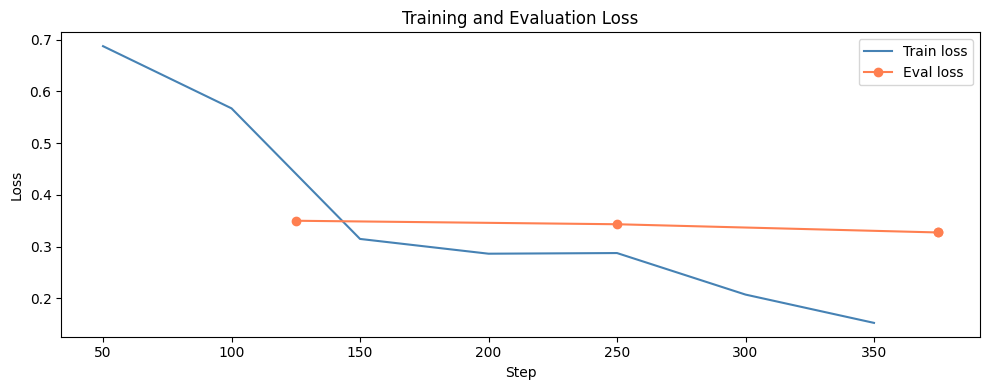

In [12]:
# Extract training loss from the trainer's log history
log_history = trainer.state.log_history
train_steps = [x['step'] for x in log_history if 'loss' in x]
train_losses = [x['loss'] for x in log_history if 'loss' in x]
eval_steps = [x['step'] for x in log_history if 'eval_loss' in x]
eval_losses = [x['eval_loss'] for x in log_history if 'eval_loss' in x]

plt.figure(figsize=(10, 4))
if train_steps:
    plt.plot(train_steps, train_losses, label='Train loss', color='steelblue')
if eval_steps:
    plt.plot(eval_steps, eval_losses, label='Eval loss', color='coral', marker='o')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training and Evaluation Loss')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Zero-Shot Comparison

Let's compare our fine-tuned model against a zero-shot classification baseline.

In [13]:
zero_shot = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=0 if torch.cuda.is_available() else -1,
)

candidate_labels = ["positive review", "negative review"]

sample_reviews = test_reviews[:3]
print("Zero-shot vs Fine-tuned comparison:")
print("-" * 70)
for rev in sample_reviews:
    zs_result = zero_shot(rev, candidate_labels)
    ft_result = sentiment_pipeline(rev)[0]
    zs_label = "POSITIVE" if zs_result['labels'][0] == "positive review" else "NEGATIVE"
    print(f"Review  : {rev[:65]}...")
    print(f"Zero-shot : {zs_label:<10} (score: {zs_result['scores'][0]:.4f})")
    print(f"Fine-tuned: {ft_result['label']:<10} (score: {ft_result['score']:.4f})")
    print()

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Zero-shot vs Fine-tuned comparison:
----------------------------------------------------------------------
Review  : This movie was absolutely fantastic! The acting was superb and th...
Zero-shot : POSITIVE   (score: 0.9963)
Fine-tuned: POSITIVE   (score: 0.9768)

Review  : Terrible film. The story made no sense and the special effects we...
Zero-shot : NEGATIVE   (score: 0.9943)
Fine-tuned: NEGATIVE   (score: 0.9719)

Review  : It was an okay movie. Not great, not terrible. Some parts were en...
Zero-shot : NEGATIVE   (score: 0.5701)
Fine-tuned: NEGATIVE   (score: 0.7522)



## 11. Summary

In this notebook we:
- Loaded the IMDb dataset and explored its class distribution
- Tokenized and preprocessed reviews for DistilBERT
- Fine-tuned with the Hugging Face `Trainer` API
- Evaluated with accuracy, precision, recall, F1, and a confusion matrix
- Ran inference on custom movie reviews
- Compared our fine-tuned model to zero-shot classification

**Extension Ideas**
- Fine-tune on other sentiment datasets (Yelp, Twitter, product reviews)
- Add a 3-class setup (negative / neutral / positive)
- Experiment with larger models (BERT-base, RoBERTa) for higher accuracy
- Incorporate aspect-based sentiment analysis
- Build a Gradio or Streamlit app for live sentiment demo

---

🎉 **Congratulations!** You have completed all five NLP notebooks:
1. `01_text_generation.ipynb` — GPT-2 autoregressive text generation
2. `02_conversational_chatbot.ipynb` — BlenderBot multi-turn chatbot
3. `03_translation.ipynb` — T5 / MarianMT neural translation + BLEU evaluation
4. `04_question_answering.ipynb` — Extractive QA with DistilBERT + EM/F1 metrics
5. `05_sentiment_classification.ipynb` — Fine-tuning DistilBERT for sentiment